# Lab 12 — `MODE_NAV_SEG` bench test

Fire one segment at a time by setting the target via `SET_NAV_TARGET` and then triggering the run with `START_RECORD` (same code path every other lab uses to start a recording — it re-initializes the ToF + IMU before kicking off the FSM). Per-tick data is pulled back later via plain `SEND_LOG` (lab7 / lab9 pattern). Two modes are exposed:
* time-based stop (default) — `t_stop = commanded_dist / v_calib`
* KF-integrated stop — `nav_dist_traveled_m ≥ commanded_dist`

`NAV_DONE` no longer notifies; the final pose is just the last sample in the `SEND_LOG` stream.

## Setup

In [279]:
%load_ext autoreload
%autoreload 2

import time
import numpy as np

from ble import get_ble_controller
from base_ble import LOG
from cmd_types import CMD

LOG.propagate = False

# Mirrors ControlMode in ble_arduino.ino. Keep in sync if you reorder.
# Current order: POSITION=0 ORIENTATION=1 RUSH=2 IDLE=3 FLIP=4 MAPPING=5
#                BUG=6 NAV_SEG=7   (MODE_NAVIGATION was removed)
MODE_NAV_SEG = 7
MODE_IDLE    = 3

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [280]:
ble = get_ble_controller()
ble.connect()

2026-05-13 16:31:57,680 | INFO     |: Looking for Artemis Nano Peripheral Device: c0:42:0c:78:b8:49
2026-05-13 16:31:57,680 | INFO     |: Scanning for device with address: c0:42:0c:78:b8:49, service UUID: d427e7cc-c400-4597-b417-d564e20d6600
2026-05-13 16:32:07,735 | INFO     |: Found 1 device(s) advertising service d427e7cc-c400-4597-b417-d564e20d6600
2026-05-13 16:32:07,736 | INFO     |: Selecting device: 3AE32BFA-4071-EC2D-ED7A-60CCA92DBE18 (name: Artemis BLE)
2026-05-13 16:32:08,602 | INFO     |: Connected to c0:42:0c:78:b8:49


In [235]:
ble.send_command(CMD.PING, "")

## Log handler

In [281]:
times             = []
left_pwm_values   = []
right_pwm_values  = []
acc_x_values      = []
tof_2_values      = []
kfpos_values      = []   # dist_sensor_buffer = dist_pid.kfPosition() in NAV_GO
yaw_values        = []

last_ack = {}            # kept for compatibility — NAV_DONE no longer notifies


def log_handler(sender, data: bytearray):
    msg = ble.bytearray_to_string(data)
    parts = msg.split("|")
    if len(parts)== 7:
        t    = float(parts[0][2:])
        lpwm = float(parts[1][5:])
        rpwm = float(parts[2][5:])
        ax   = float(parts[3][3:])
        t2   = float(parts[4][3:])
        dv   = float(parts[5][3:])
        yw   = float(parts[6][3:])

    times.append(t)
    left_pwm_values.append(lpwm)
    right_pwm_values.append(rpwm)
    acc_x_values.append(ax)
    tof_2_values.append(t2)
    kfpos_values.append(dv)
    yaw_values.append(yw)
    
    print (f"t: {t:.2f}, lm: {lpwm:.2f}, rm: {rpwm:.2f}, ax: {ax:.2f}, t2: {t2:.2f}")


ble.start_notify(ble.uuid["RX_STRING"], log_handler)
print("Log handler attached.")

Log handler attached.


In [267]:
ble.stop_notify(ble.uuid["RX_STRING"])

## Enter `MODE_NAV_SEG` and push calibration

Setting the mode just parks the FSM at `NAV_IDLE`. Calibration values are remembered until reboot; re-push when you swap the battery.

In [282]:
ble.send_command(CMD.SET_MODE, str(MODE_NAV_SEG))
ble.send_command(CMD.UPDATE_ORIENT_PID, "2.5|1.2|0.25")
ble.send_command(CMD.SET_NAV_CALIB, "70|1.76")          # pwm | speed_mps
print("NAV_SEG mode entered, PID + calibration pushed.")

NAV_SEG mode entered, PID + calibration pushed.


## Helpers

* `reset_yaw()` — zero the relative-yaw reference at the current heading.
* `set_dist_mode(use_kf)` — `0` = stop on calibrated time, `1` = stop on KF integrated distance.
* `send_segment(seg_id, heading, dist_m, seg_wait)` — fire one segment, sleep through it, return `last_ack`. **Does not pull the log** — call `fetch_log()` separately if you want per-tick data.
* `fetch_log(wait_s=60)` — clear the buffers, send `SEND_LOG`, sleep, and the handler fills the lists. Long sleep matches lab7/lab9.

In [283]:
def reset_yaw():
    ble.send_command(CMD.RESET_YAW, "")
    time.sleep(0.2)
    print("Yaw reset.")


def set_dist_mode(use_kf):
    ble.send_command(CMD.SET_NAV_DIST_MODE, "1" if use_kf else "0")
    time.sleep(0.1)
    print(f"Dist mode: {'KF-integrated' if use_kf else 'time-based'}")


def reset_buffers():
    times.clear()
    left_pwm_values.clear()
    right_pwm_values.clear()
    acc_x_values.clear()
    tof_2_values.clear()
    kfpos_values.clear()
    yaw_values.clear()


def send_segment(seg_id, heading_deg, dist_m, seg_wait=3.0):
    """Two-step kickoff:
      1. SET_NAV_TARGET stores heading / distance / seg_id on the robot.
      2. START_RECORD re-runs the ToF + IMU init path, seeds the FSM at
         NAV_TURN, and arms `active` + `collecting` — exactly the path
         every other lab uses to start a run.

    NAV_DONE no longer notifies, so `last_ack` stays empty. Returns None.
    `seg_wait` should cover TURN + STABILIZE + GO.
    """
    last_ack.clear()
    print(f"-> seg {seg_id}: heading {heading_deg:+.1f}°, dist {dist_m:.3f} m")
    ble.send_command(CMD.SET_NAV_TARGET, f"{heading_deg}|{dist_m}|{seg_id}")
    time.sleep(0.1)
    ble.send_command(CMD.START_RECORD, "")
    time.sleep(seg_wait)


def fetch_log(wait_s=60.0):
    """Reset buffers, ask for SEND_LOG, sleep for the stream — lab9 style."""
    reset_buffers()
    ble.send_command(CMD.SEND_LOG, "")
    print(f"  fetching log (waiting {wait_s:.0f}s)...")
    time.sleep(wait_s)
    print(f"  pulled {len(times)} samples")

## Reset yaw

In [284]:
reset_yaw()

Yaw reset.


## Single segment

In [254]:
send_segment(1, heading_deg=0.0, dist_m=1.0, seg_wait=3.0)

-> seg 1: heading +0.0°, dist 1.000 m


## Iterative speed calibration

1. Edit `TEST_*` in cell A.
2. Run cell B (shot).
3. Tape-measure the actual travel, set `ACTUAL_DIST_M` in cell C, run it — it back-solves `v_calib` and pushes the new value.
4. Re-run cell B to verify.

In [255]:
# A — state
TEST_PWM    = 70.0
TEST_SPEED  = 1.76    # m/s at TEST_PWM (refined by the update cell)
TEST_DIST_M = 1.00

In [256]:
# B — shot
ble.send_command(CMD.SET_NAV_CALIB, f"{TEST_PWM}|{TEST_SPEED}")
reset_yaw()
send_segment(99, heading_deg=0.0, dist_m=TEST_DIST_M, seg_wait=6.0)

Yaw reset.
-> seg 99: heading +0.0°, dist 1.000 m


In [149]:
# C — update v_calib from tape reading
ACTUAL_DIST_M = 1.00    # <-- ruler measurement

# Stop condition is time-based: t = TEST_DIST_M / v_calib.
# Travel = t * v_actual. Solving: v_actual = (actual / commanded) * v_calib.
v_actual = (ACTUAL_DIST_M / TEST_DIST_M) * TEST_SPEED
TEST_SPEED = v_actual
ble.send_command(CMD.SET_NAV_CALIB, f"{TEST_PWM}|{TEST_SPEED}")
print(f"v_calib updated -> {TEST_SPEED:.3f} m/s. Re-run cell B to verify.")

v_calib updated -> 1.760 m/s. Re-run cell B to verify.


## Time-based vs KF-integrated stop

Each side fires one segment, then `fetch_log()` pulls the per-tick samples back over a long sleep. The buffers are snapshotted into a flat dict and written to `.npz` before the next run.

In [285]:
COMPARE_DIST_M = 1.00
COMPARE_HEAD   = 0.0
SEG_WAIT_S     = 3.0      # cover TURN + STABILIZE + GO + SETTLE
LOG_WAIT_S     = 60.0     # generous for SEND_LOG streaming

In [286]:
# Run 1: time-based stop. Re-point the robot at heading 0° before running.
set_dist_mode(False)
reset_yaw()
ack_t = send_segment(300, COMPARE_HEAD, COMPARE_DIST_M, seg_wait=SEG_WAIT_S)

Dist mode: time-based
Yaw reset.
-> seg 300: heading +0.0°, dist 1.000 m


In [287]:
reset_buffers()
ble.send_command(CMD.SEND_LOG, "")

t: 7.00, lm: 0.00, rm: 0.00, ax: 0.00, t2: 1448.00
t: 18.00, lm: -34.00, rm: 42.00, ax: 20.02, t2: 1448.00
t: 29.00, lm: -34.00, rm: 42.00, ax: 20.02, t2: 1448.00
t: 51.00, lm: -34.00, rm: 42.00, ax: 26.12, t2: 1448.00
t: 67.00, lm: 29.00, rm: -46.00, ax: 76.90, t2: 1448.00
t: 84.00, lm: 29.00, rm: -47.00, ax: 37.35, t2: 1462.00
t: 105.00, lm: 29.00, rm: -46.00, ax: -33.69, t2: 1462.00
t: 122.00, lm: -34.00, rm: 42.00, ax: 143.07, t2: 1462.00
t: 142.00, lm: -34.00, rm: 42.00, ax: -43.46, t2: 1462.00
t: 167.00, lm: -34.00, rm: 42.00, ax: 79.10, t2: 1462.00
t: 178.00, lm: 29.00, rm: -46.00, ax: -10.25, t2: 1462.00
t: 195.00, lm: 30.00, rm: -47.00, ax: 38.33, t2: 1456.00
t: 210.00, lm: 30.00, rm: -47.00, ax: 38.33, t2: 1456.00
t: 239.00, lm: 29.00, rm: -46.00, ax: 74.46, t2: 1456.00
t: 249.00, lm: 161.00, rm: 191.00, ax: 36.13, t2: 1456.00
t: 269.00, lm: 161.00, rm: 191.00, ax: 47.61, t2: 1456.00
t: 288.00, lm: 161.00, rm: 190.00, ax: 464.60, t2: 1455.00
t: 299.00, lm: 162.00, rm: 190.00,

In [288]:
A_t = dict(
    t    = np.array(times,            dtype=float),
    lpwm = np.array(left_pwm_values,  dtype=float),
    rpwm = np.array(right_pwm_values, dtype=float),
    acc  = np.array(acc_x_values,     dtype=float),
    tof  = np.array(tof_2_values,     dtype=float),
    kfpos= np.array(kfpos_values,     dtype=float),
    yaw  = np.array(yaw_values,       dtype=float),
)
np.savez("lab12_time_mode.npz", **A_t)
print(f"time mode -> lab12_time_mode.npz ({len(A_t['t'])} samples)")

time mode -> lab12_time_mode.npz (208 samples)


In [289]:
# Run 2: KF-integrated stop. Re-point the robot at heading 0° first.
set_dist_mode(True)
reset_yaw()
ack_k = send_segment(301, COMPARE_HEAD, COMPARE_DIST_M, seg_wait=SEG_WAIT_S)

Dist mode: KF-integrated
Yaw reset.
-> seg 301: heading +0.0°, dist 1.000 m


In [290]:
reset_buffers()
ble.send_command(CMD.SEND_LOG, "")

t: 12.00, lm: 29.00, rm: -46.00, ax: 23.68, t2: 1425.00
t: 28.00, lm: 29.00, rm: -46.00, ax: 23.68, t2: 1425.00
t: 39.00, lm: 29.00, rm: -46.00, ax: 27.10, t2: 1425.00
t: 67.00, lm: 29.00, rm: -46.00, ax: -46.39, t2: 1425.00
t: 82.00, lm: -34.00, rm: 42.00, ax: 66.65, t2: 1425.00
t: 97.00, lm: -34.00, rm: 42.00, ax: 109.62, t2: 1425.00
t: 125.00, lm: 29.00, rm: -46.00, ax: 23.19, t2: 1442.00
t: 142.00, lm: 29.00, rm: -46.00, ax: 63.72, t2: 1442.00
t: 153.00, lm: -34.00, rm: 42.00, ax: -14.40, t2: 1442.00
t: 168.00, lm: -34.00, rm: 42.00, ax: -14.40, t2: 1442.00
t: 194.00, lm: -35.00, rm: 43.00, ax: -102.54, t2: 1442.00
t: 214.00, lm: -34.00, rm: 42.00, ax: 77.88, t2: 1442.00
t: 244.00, lm: -34.00, rm: 42.00, ax: -26.86, t2: 1436.00
t: 252.00, lm: 161.00, rm: 191.00, ax: -5.13, t2: 1436.00
t: 263.00, lm: 158.00, rm: 192.00, ax: -5.13, t2: 1436.00
t: 285.00, lm: 159.00, rm: 192.00, ax: 30.76, t2: 1436.00
t: 307.00, lm: 159.00, rm: 192.00, ax: 54.69, t2: 1436.00
t: 330.00, lm: 161.00, rm:

In [291]:
A_k = dict(
    t    = np.array(times,            dtype=float),
    lpwm = np.array(left_pwm_values,  dtype=float),
    rpwm = np.array(right_pwm_values, dtype=float),
    acc  = np.array(acc_x_values,     dtype=float),
    tof  = np.array(tof_2_values,     dtype=float),
    kfpos= np.array(kfpos_values,     dtype=float),
    yaw  = np.array(yaw_values,       dtype=float),
)
np.savez("lab12_kf_mode.npz", **A_k)
print(f"kf mode   -> lab12_kf_mode.npz   ({len(A_k['t'])} samples)")

kf mode   -> lab12_kf_mode.npz   (272 samples)


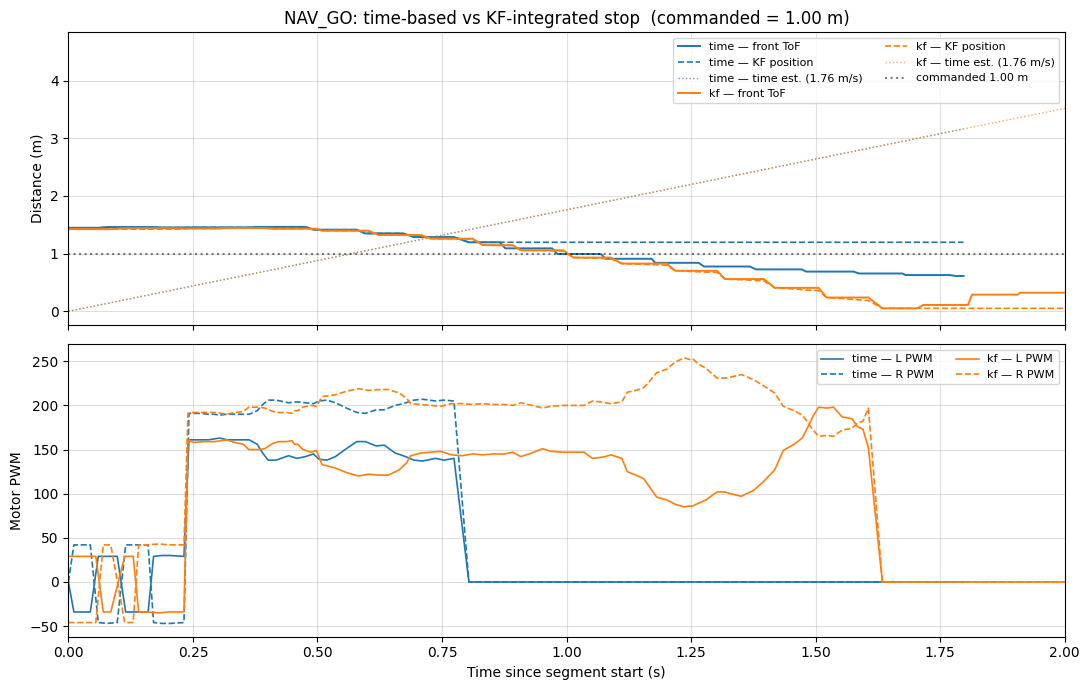

In [293]:
import os
import matplotlib.pyplot as plt

def _load(path):
    if not os.path.exists(path):
        print(f"!! {path} not found — run the corresponding cell first")
        return None
    return dict(np.load(path))

A_t = _load("lab12_time_mode.npz")
A_k = _load("lab12_kf_mode.npz")

def add_run(ax_top, ax_bot, arrs, label, color):
    if arrs is None or len(arrs.get("t", [])) == 0:
        return
    t_s   = (arrs["t"] - arrs["t"][0]) / 1000.0    # ms -> s
    tof_m = arrs["tof"]   / 1000.0                  # mm -> m
    kf_m  = arrs["kfpos"] / 1000.0
    est_m = t_s * TEST_SPEED                        # what time-mode FSM "thinks"

    ax_top.plot(t_s, tof_m, color=color, linestyle="-",
                linewidth=1.4, label=f"{label} — front ToF")
    ax_top.plot(t_s, kf_m,  color=color, linestyle="--",
                linewidth=1.2, label=f"{label} — KF position")
    ax_top.plot(t_s, est_m, color=color, linestyle=":",
                linewidth=1.0, alpha=0.7,
                label=f"{label} — time est. ({TEST_SPEED:.2f} m/s)")

    ax_bot.plot(t_s, arrs["lpwm"], color=color, linestyle="-",
                linewidth=1.2, label=f"{label} — L PWM")
    ax_bot.plot(t_s, arrs["rpwm"], color=color, linestyle="--",
                linewidth=1.2, label=f"{label} — R PWM")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
add_run(ax1, ax2, A_t, "time", "tab:blue")
add_run(ax1, ax2, A_k, "kf",   "tab:orange")

ax1.axhline(COMPARE_DIST_M, color="k", linestyle=":", alpha=0.5,
            label=f"commanded {COMPARE_DIST_M:.2f} m")
ax1.set_ylabel("Distance (m)")
ax1.set_title(f"NAV_GO: time-based vs KF-integrated stop  "
              f"(commanded = {COMPARE_DIST_M:.2f} m)")
ax1.legend(fontsize=8, loc="best", ncol=2)
ax1.grid(True, alpha=0.4)

ax2.set_ylabel("Motor PWM")
ax2.set_xlabel("Time since segment start (s)")
ax2.legend(fontsize=8, loc="best", ncol=2)
ax2.grid(True, alpha=0.4)

ax1.set_xlim(0,2)
ax2.set_xlim(0,2)

plt.tight_layout()
plt.savefig("lab12_compare.png", dpi=130)
plt.show()

## Stop / disconnect

In [ ]:
ble.send_command(CMD.SET_MODE, str(MODE_IDLE))
reset_buffers()
ble.send_command(CMD.START_RECORD, "")
time.sleep(5)
ble.send_command(CMD.SEND_LOG, "")

time=9.000s lpwm=0.0 rpwm=0.0 acc_x=0.00 tof_2=758 dv=758.000 yw=+3.6°
time=11.000s lpwm=0.0 rpwm=0.0 acc_x=0.00 tof_2=758 dv=758.000 yw=+3.6°
time=18.000s lpwm=0.0 rpwm=0.0 acc_x=0.00 tof_2=758 dv=758.000 yw=+3.6°
time=28.000s lpwm=0.0 rpwm=0.0 acc_x=11.23 tof_2=758 dv=758.000 yw=+3.6°
time=30.000s lpwm=0.0 rpwm=0.0 acc_x=11.23 tof_2=758 dv=758.000 yw=+3.6°
time=38.000s lpwm=0.0 rpwm=0.0 acc_x=15.14 tof_2=758 dv=758.000 yw=+3.6°
time=45.000s lpwm=0.0 rpwm=0.0 acc_x=15.14 tof_2=758 dv=758.000 yw=+3.6°
time=47.000s lpwm=0.0 rpwm=0.0 acc_x=15.14 tof_2=758 dv=758.000 yw=+3.6°
time=53.000s lpwm=0.0 rpwm=0.0 acc_x=18.07 tof_2=758 dv=758.000 yw=+3.6°
time=55.000s lpwm=0.0 rpwm=0.0 acc_x=18.07 tof_2=758 dv=758.000 yw=+3.6°
time=60.000s lpwm=0.0 rpwm=0.0 acc_x=18.07 tof_2=758 dv=758.000 yw=+3.6°
time=62.000s lpwm=0.0 rpwm=0.0 acc_x=18.07 tof_2=758 dv=758.000 yw=+3.6°
time=64.000s lpwm=0.0 rpwm=0.0 acc_x=18.07 tof_2=758 dv=758.000 yw=+3.6°
time=70.000s lpwm=0.0 rpwm=0.0 acc_x=18.07 tof_2=758 dv

In [233]:
ble.send_command(CMD.STOP_ROBOT, "")
ble.send_command(CMD.SET_MODE, str(MODE_IDLE))
ble.stop_notify(ble.uuid["RX_STRING"])
print("Motors off, notify detached.")

Exception: Not connected to a BLE device

In [ ]:
ble.disconnect()